# Vision Transformer (ViT) Fine-tuning Notebook
Bu notebook ön-eğitimli bir ViT modelini kendi veri kümeniz üzerinde fine-tune etmek için hazırlanmıştır.
NOT: Lütfen `dataset_dir` değişkenini veri kümenizin kök yoluna göre güncelleyin (ör. `C:/.../dataset`). Veri kümesi klasör yapısı `train/` ve `test/` alt klasörleri içermeli ve her biri sınıf alt-klasörleri barındırmalıdır.

## Imports
Bu hücre gerekli kütüphanelerin import edildiği yerdir.

In [19]:
# Imports
# Required libraries and utilities (plots, metrics, model helpers)
import os
import time
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

## Configuration
Veri yolu ve eğitim hiperparametrelerini (batch size, epoch sayısı, learning rate vb.) buradan ayarlayın.

In [20]:
# Configuration
# Update dataset path and training hyperparameters below
# dataset_dir = 'C:\\Users\\emirh\\Desktop\\Projects\\CNN\\DermiumNet\\dataset\\input_sk'
dataset_dir = 'E:/Github/DermiumNet/datasets/isic2019/dataset_2'
train_dir = os.path.join(dataset_dir, 'train')
test_dir = os.path.join(dataset_dir, 'test')
image_size = 224  # ViT tipik boyutu
batch_size = 32
num_workers = 4
epochs = 10  # önerilen aralık: 5-15
lr = 1e-4
weight_decay = 1e-4
model_name = 'vit_small_patch16_224'  # değiştirmek isterseniz: vit_tiny_*, vit_base_*, vb.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Data Loading and Transforms
Görüntü dönüşümleri hazırlanır ve `ImageFolder` kullanılarak `DataLoader`lar oluşturulur.

In [21]:
# Data Loading and Transforms
# Prepare train/test transforms and create DataLoaders (ImageFolder expected)
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
# Datasets: ImageFolder varsayımı
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
num_classes = len(train_dataset.classes)
print('Num classes:', num_classes)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Num classes: 8


## Model
Ön-eğitimli ViT modeli yüklenir ve sınıflandırma başlığı (`head`) `num_classes` olacak şekilde güncellenir.

In [22]:
# Model
# Load a pretrained ViT and adapt the classification head to `num_classes`
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model.to(device)
# Parametre sayısı (isteğe bağlı bilgi)
def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
print('Trainable parameters:', count_parameters(model))

Trainable parameters: 21668744


## Optimizer and Loss
Optimizatör, kayıp fonksiyonu ve (isteğe bağlı) LR scheduler burada tanımlanır.

In [23]:
# Optimizer and Loss
# Set optimizer, loss function and optional LR scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
# Basit LR scheduler (isteğe bağlı değiştirebilirsiniz)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

## Training
Eğitim döngüsü: modelin fine-tune edildiği, epoch bazlı loss ve accuracy'nin kaydedildiği hücre.

In [24]:
# Training
# Fine-tune the model. This cell logs train/val loss and accuracy per epoch
train_losses = []
val_losses = []
train_accs = []
val_accs = []
start_time = time.time()
# Use test_loader as validation if you don't have a separate val set
val_loader = test_loader
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    for images, labels in tqdm(train_loader, desc=f'Train Epoch {epoch}/{epochs}', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_corrects += torch.sum(preds == labels).item()
    scheduler.step()
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    # Validation
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Val Epoch {epoch}/{epochs}', leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_running_corrects += torch.sum(preds == labels).item()
    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = val_running_corrects / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch} - Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}')
total_time = time.time() - start_time
print(f'Training finished, elapsed time: {total_time:.1f} seconds')

Epoch 1 - Train Loss: 0.8924 Train Acc: 0.6597 | Val Loss: 0.7333 Val Acc: 0.7113


Epoch 2 - Train Loss: 0.4606 Train Acc: 0.8308 | Val Loss: 0.6014 Val Acc: 0.7688


Epoch 3 - Train Loss: 0.2750 Train Acc: 0.9018 | Val Loss: 0.5604 Val Acc: 0.7913


Epoch 4 - Train Loss: 0.1557 Train Acc: 0.9457 | Val Loss: 0.4835 Val Acc: 0.8175


Epoch 5 - Train Loss: 0.1008 Train Acc: 0.9663 | Val Loss: 0.5072 Val Acc: 0.8387


Epoch 6 - Train Loss: 0.0330 Train Acc: 0.9915 | Val Loss: 0.4104 Val Acc: 0.8625


Epoch 7 - Train Loss: 0.0082 Train Acc: 0.9982 | Val Loss: 0.4053 Val Acc: 0.8762


Epoch 8 - Train Loss: 0.0023 Train Acc: 1.0000 | Val Loss: 0.4054 Val Acc: 0.8838


Epoch 9 - Train Loss: 0.0017 Train Acc: 1.0000 | Val Loss: 0.4170 Val Acc: 0.8788


Epoch 10 - Train Loss: 0.0012 Train Acc: 0.9998 | Val Loss: 0.4265 Val Acc: 0.8850
Training finished, elapsed time: 810.6 seconds


## Save Model
Model ağırlıklarını ve sınıf listesini çalışma dizinine kaydeder.

In [25]:
# Save Model
# Persist fine-tuned model weights and class names to results/<model_name> directory
results_dir = os.path.join(os.getcwd(), 'results', model_name)
os.makedirs(results_dir, exist_ok=True)
out_path = os.path.join(results_dir, f'{model_name}_finetuned.pth')
torch.save({'model_state_dict': model.state_dict(), 'classes': train_dataset.classes}, out_path)
print('Saved model to', out_path)

Saved model to c:\Users\emirh\Desktop\Projects\SkinNet\results\vit_small_patch16_224\vit_small_patch16_224_finetuned.pth


## Inference / Predictions
Test verisi üzerinde modelin tahminlerini toplayın; sonuçlar bir sonraki hücrede görselleştirilecek.

In [26]:
# Inference / Predictions
# Run the model on the test set and collect predictions for later analysis
import numpy as np
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
# Convert to numpy arrays for downstream cells
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print('Collected', len(all_preds), 'predictions')

Predicting: 100%|██████████| 25/25 [00:08<00:00,  2.85it/s]


Collected 800 predictions


## Results: Metrics and Visualizations
Bu hücre hesaplanan metrikleri yazdırır ve eğitim/validasyon eğrilerini ile karışıklık matrisini çizer.

Accuracy: 0.8850
Precision (macro): 0.8847
Recall (macro): 0.8850
F1-score (macro): 0.8847


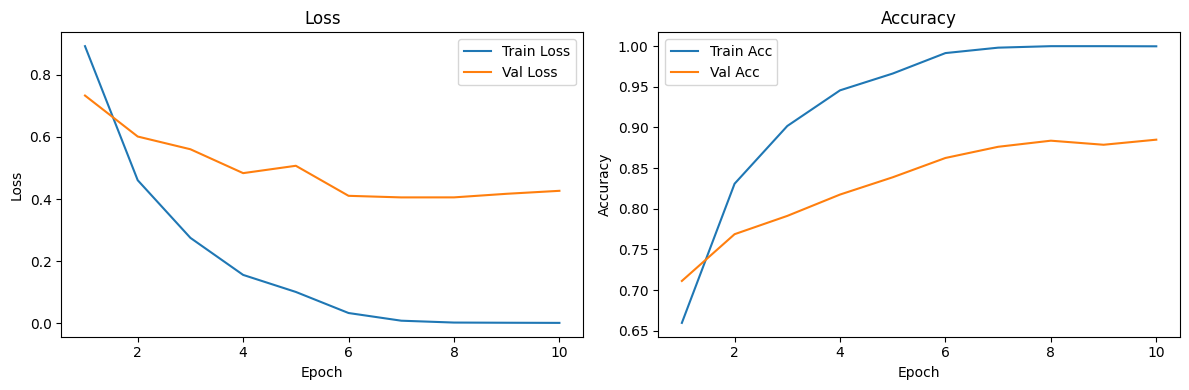

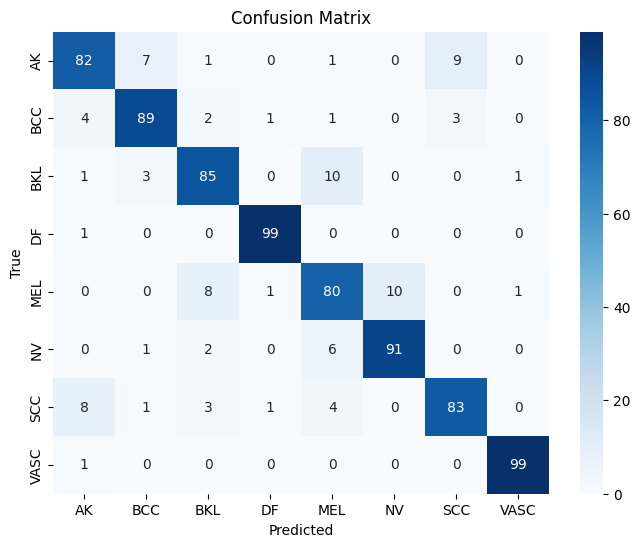

In [27]:
# Results: Metrics and Visualizations
# Compute macro metrics and plot loss/accuracy curves and confusion matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f'Accuracy: {acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall (macro): {rec:.4f}')
print(f'F1-score (macro): {f1:.4f}')
# Plot train/val loss and accuracy if recorded
try:
    epochs_range = range(1, len(train_losses)+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label='Train Acc')
    plt.plot(epochs_range, val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.tight_layout()
    # Ensure results directory exists and save the figure
    results_dir = os.path.join(os.getcwd(), 'results', model_name)
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, 'loss_acc.png'))
    plt.show()
except NameError:
    print('Train/val history not found; graphs skipped.')
# Confusion matrix
try:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    # Save confusion matrix to results folder
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.show()
except Exception as e:
    print('Could not plot confusion matrix:', e)